# Demo: Controlled Pendulum System
## Verification Co-Simulation Algorithms

In [41]:
import sys
import numpy as np
from pathlib import Path
import time
import scipy
from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from docs.plot_setup import set_professional_style
plt = set_professional_style()

from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent
from SysSimX.system.connection import Connection
from SysSimX.system.system import System
from SysSimX.viz.sysgraph import SystemGraphVisualizer

### 1. General Simulation Setup

In [37]:
t0 = 0
dt_values = [0.02, 0.01, 0.005, 0.001]
t_end = 0.5

### 2. Monolithic Model - Reference Solution

- The monolithic Modelica model for the controlled pendulum system is used as reference solution for the verification of the co-simulation algorithms.
- The system model is monolithical because in Modelica, all subsystems are white box models and all involved euqations, including algebraic equations, are solved simultaneously by the Modelica solver DASSL.
- The simple model has no strong algebraic coupling. There is a torque connection (drive to pendulum) and angular velocity connection (pendulum to drive) between the drive and pendulum subsystems.



In [24]:
# 1) Build the Modelica Model
pkg_dir_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum'
pkg_file_path = pkg_dir_path / 'package.mo'

models = ('ControlledPendulum.Demo_Driven', 'ControlledPendulum.Demo_Driven_Coupled')
cases = ('simple', 'complex')

dt_monolithic = 1e-4
solver_tolerance = 1e-8
solver_monolithic = 'dassl'

ref_res = {}
for model, case in zip(models, cases):
    print(60 * "=")
    print(f'Starting Monolithic Simulation - Type: {case}')
    print(60 * "=")

    # 1) Create Modelica System Model
    model = ModelicaSystem(str(pkg_file_path), model)
    
    # 2) Set Simulation Options, Build and Simulate
    simulation_options = [
        f"startTime={t0}",
        f"stopTime={t_end}",        
        f"stepSize={dt_monolithic}",
        f"tolerance={solver_tolerance}",
        f"solver={solver_monolithic}"
        ]
    #model.setOptimizationOptions(f"numberOfIntervals={int(t_end/dt_monolithic)}")
    model.setSimulationOptions(simulation_options)
    model.buildModel()

    start_time = time.time()

    model.simulate()

    # 3) Extract and Save Results
    solutions_dict = {}
    solutions = model.getSolutions()
    for sol in solutions:
        solutions_dict[sol] = model.getSolutions(sol)
    end_time = time.time()
    ref_res[case] = solutions_dict

    # 4) Save Results to .mat file
    res_file = Path.cwd() / f'results/monolithic_{case}.mat'
    scipy.io.savemat(str(res_file), solutions_dict, long_field_names=True)

    print(f'Monolithic Simulation Completed in {end_time - start_time:.2f} seconds.')

Starting Monolithic Simulation - Type: simple

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
Monolithic Simulation Completed in 38.24 seconds.
Starting Monolithic Simulation - Type: complex

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation fini

In [25]:
for case in ref_res:
    for key in ref_res[case]:
        if isinstance(ref_res[case][key], np.ndarray):
            ref_res[case][key] = ref_res[case][key].flatten()

t_simple = ref_res['simple']['time']
t_complex = ref_res['complex']['time']

q_ref = ref_res['simple']['reference.q_ref']

theta_simple = ref_res['simple']['pendulum.q']
theta_complex = ref_res['complex']['pendulum.q']

omega_simple = ref_res['simple']['pendulum.omega']
omega_complex = ref_res['complex']['pendulum.omega']

alpha_simple = ref_res['simple']['pendulum.alpha']
alpha_complex = ref_res['complex']['pendulum.alpha']

torque_simple = ref_res['simple']['drive.torque']
torque_complex = ref_res['complex']['drive.torque']

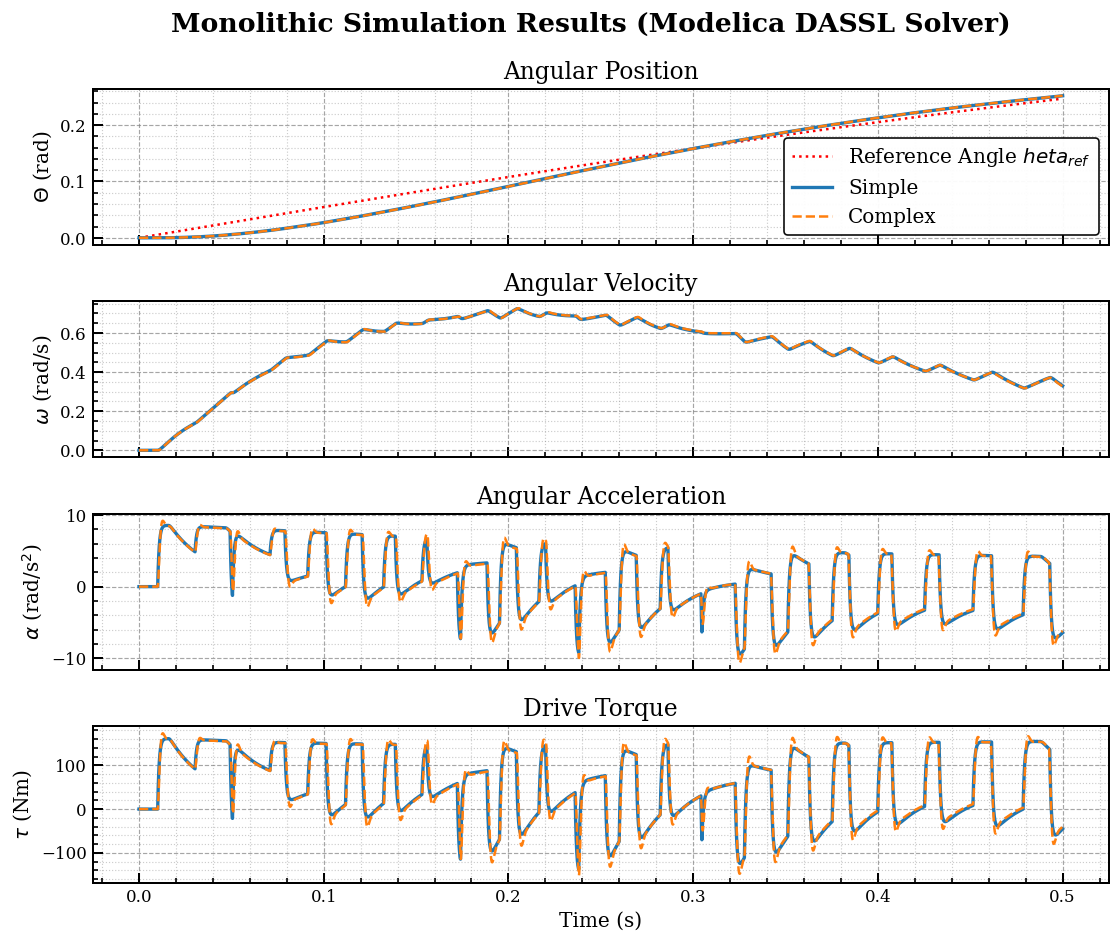

In [26]:
style_simple = {'color': 'tab:blue', 'linestyle': '-', 'label': 'Simple', 'linewidth': 2}
style_complex = {'color': 'tab:orange', 'linestyle': '--', 'label': 'Complex', 'linewidth': 1.5}

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

fig.suptitle('Monolithic Simulation Results (Modelica DASSL Solver)', fontsize=16, fontweight='bold')

axs[0].set_title(r'Angular Position')
axs[0].plot(t_simple, q_ref, label='Reference Angle $\theta_{ref}$', color='red', linestyle=':', linewidth=1.5)
axs[0].plot(t_simple, theta_simple, **style_simple)
axs[0].plot(t_complex, theta_complex, **style_complex)
axs[0].set_ylabel(r'$\Theta$ (rad)')
axs[0].legend()

axs[1].set_title(r'Angular Velocity')
axs[1].plot(t_simple, omega_simple, **style_simple)
axs[1].plot(t_complex, omega_complex, **style_complex)
axs[1].set_ylabel(r'$\omega$ (rad/s)')

axs[2].set_title(r'Angular Acceleration')
axs[2].plot(t_simple, alpha_simple, **style_simple)
axs[2].plot(t_complex, alpha_complex, **style_complex)
axs[2].set_ylabel(r'$\alpha$ (rad/s$^2$)')

axs[3].set_title(r'Drive Torque')
axs[3].plot(t_simple, torque_simple, **style_simple)
axs[3].plot(t_complex, torque_complex, **style_complex)
axs[3].set_ylabel(r'$\tau$ (Nm)')
axs[3].set_xlabel('Time (s)')

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major', linestyle='--', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)


# adjust layout and add vertical space
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.subplots_adjust(top=0.9)
plt.show()

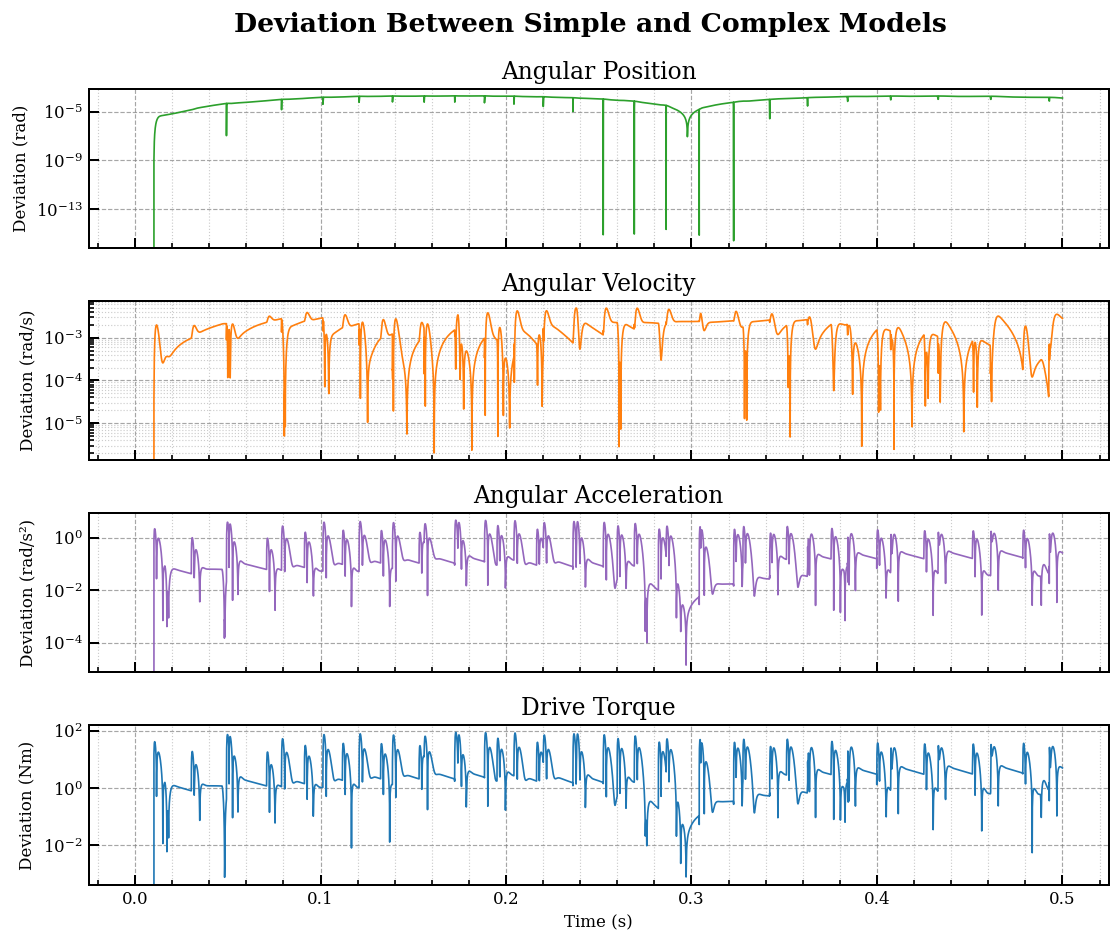

In [31]:
# Claculate relative deviation between both models
eps = 1e-10
theta_diff = np.abs(theta_simple - theta_complex) 
omega_diff = np.abs(omega_simple - omega_complex) 
alpha_diff = np.abs(alpha_simple - alpha_complex) 
torque_diff = np.abs(torque_simple - torque_complex)

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Deviation Between Simple and Complex Models', fontsize=16, fontweight='bold')
axs[0].set_title(r'Angular Position')
axs[0].semilogy(t_simple, theta_diff, color='tab:green', linestyle='-', linewidth=1)
axs[0].set_ylabel(r'Deviation (rad)', fontsize=10)

axs[1].set_title(r'Angular Velocity')
axs[1].semilogy(t_simple, omega_diff, color='tab:orange', linestyle='-', linewidth=1)
axs[1].set_ylabel(r'Deviation (rad/s)', fontsize=10)

axs[2].set_title(r'Angular Acceleration')
axs[2].semilogy(t_simple, alpha_diff, color='tab:purple', linestyle='-', linewidth=1)
axs[2].set_ylabel(r'Deviation (rad/s²)', fontsize=10)
    
axs[3].set_title(r'Drive Torque')
axs[3].semilogy(t_simple, torque_diff, color='tab:blue', linestyle='-', linewidth=1)
axs[3].set_ylabel(r'Deviation (Nm)', fontsize=10)
axs[3].set_xlabel('Time (s)', fontsize=10)

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major', linestyle='--', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)

# adjust layout and add vertical space
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.subplots_adjust(top=0.9)
plt.show()




### 3. SysSimX Co-Simulation Algorithms

In [38]:
algorithms = ('Jacobi', 'Gauss-Seidel', 'IJCSA')

#### 3.1 Generate FMUComponents

In [39]:
demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=True)

print(60 * "=")
print('FMU Paths:')
for name, path in fmu_paths.items():
    print(f'  {name}: {path}')
print(60 * "=")

ref           = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Reference')
sensor_ref    = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state  = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid           = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive         = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
drive_coupled = FMUComponent(name='drive_coupled', fmu_path=fmu_paths['Drive_Coupled'], group='Actuator')
pendulum      = FMUComponent(name='pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

################################################################################
Processing model: ControlledPendulum.AngleEncoder

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


FMU for ControlledPendulum.AngleEncoder moved to:
/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu

################################################################################
Processing model: ControlledPendulum.Demo_Driven

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


FMU for ControlledPendulum.Demo_Driven moved to:
/ho

#### 3.2 Simple Coupled Co-Simulation

Execution Order (generations):
['pendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']
['drive']

Algebraic Loops:


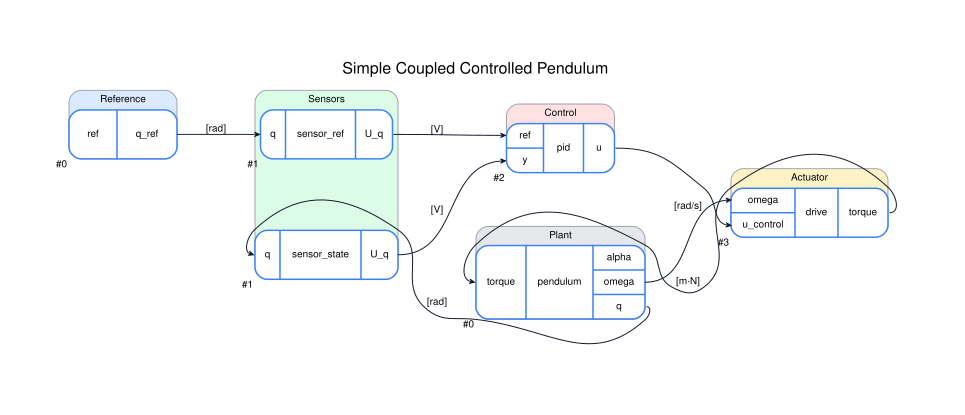

Simulating Simple Coupled System with Jacobi and dt=0.02...
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER  

In [5]:
c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

system = System(name="Simple Coupled Controlled Pendulum")
for comp in components:
    system.add_component(comp)
for conn in connections:
    system.add_connection(conn)

simple_system = system
simple_system.compute_execution_order()

print("Execution Order (generations):")
for gen in simple_system.execution_order:
    print(gen)

print("\nAlgebraic Loops:")
for loop in simple_system.algebraic_loops:
    print(loop)

visualizer = SystemGraphVisualizer(simple_system)
visualizer.visualize()
visualizer.save("figures/ControlledPendulumSimple.svg")

# Run simulations for different algorithms and time steps
results = {}
res_dir = Path.cwd() / 'results/cs_simple'
res_dir.mkdir(parents=True, exist_ok=True)

for algorithm in algorithms:
    results[algorithm] = {}
    res_alg_dir = res_dir / algorithm
    res_alg_dir.mkdir(parents=True, exist_ok=True)
    for dt in dt_values:
        simple_system.history.clear()
        print(f'Simulating Simple Coupled System with {algorithm} and dt={dt}...')
        simple_system.algorithm = algorithm
        simple_system.initialize(t0, t_end)
        simple_system.run(t0, t_end, dt)
        res_file = res_alg_dir / f'simple_{algorithm}_dt_{dt:.3f}.csv'
        simple_system.history.save_csv(filepath=res_file)

#### 3.3 Complex Coupled Co-Simulation

Execution Order (generations):
['drive_coupled', 'pendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']

Algebraic Loops:
['drive_coupled', 'pendulum']


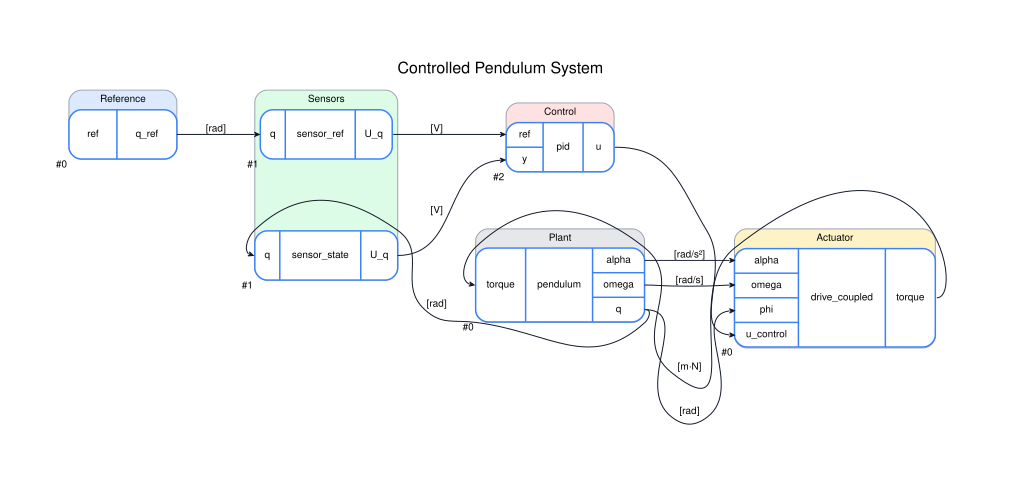

Simulating Complex Coupled System with Jacobi and dt=0.02...
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER 

In [6]:
c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['u_control'].name)

c6 = Connection(src_comp=drive_coupled.name, src_port=drive_coupled.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7a = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['phi'].name)
c7b = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['omega'].name)
c7c = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['alpha'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['alpha'].name)

connections = [c1, c2, c3, c4, c5, c6, c7a, c7b, c7c]
components = [ref, sensor_ref, sensor_state, pid, drive_coupled, pendulum]

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

complex_system = system
complex_system.compute_execution_order()

print("Execution Order (generations):")
for gen in complex_system.execution_order:
    print(gen)

print("\nAlgebraic Loops:")
for loop in complex_system.algebraic_loops:
    print(loop)

visualizer = SystemGraphVisualizer(complex_system)
visualizer.visualize()
visualizer.save("figures/ControlledPendulumComplex.svg")

# Run simulations for different algorithms and time steps
results = {}
res_dir = Path.cwd() / 'results/cs_complex'
res_dir.mkdir(parents=True, exist_ok=True)

for algorithm in algorithms:
    results[algorithm] = {}
    res_alg_dir = res_dir / algorithm
    res_alg_dir.mkdir(parents=True, exist_ok=True)
    for dt in dt_values:
        complex_system.history.clear()
        print(f'Simulating Complex Coupled System with {algorithm} and dt={dt}...')
        complex_system.algorithm = algorithm
        complex_system.initialize(t0, t_end)
        complex_system.run(t0, t_end, dt)
        res_file = res_alg_dir / f'complex_{algorithm}_dt_{dt:.3f}.csv'
        complex_system.history.save_csv(filepath=res_file)